<a href="https://www.kaggle.com/code/obaidah/asr-preprocessing?scriptVersionId=311034418" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 🎤 Arabic ASR System

### Deep Learning Based Arabic Audio Understanding and Retrieval System

**Original dataset / Reference:**
[Mozilla Common Voice Dataset](https://commonvoice.mozilla.org)

---

## 1. Introduction

This notebook focuses on the preprocessing pipeline for an Arabic ASR system.

The goal of preprocessing is to transform raw audio and text data into a clean, consistent, and model-ready format.

A robust preprocessing pipeline is a critical component in any Automatic Speech Recognition (ASR) system, particularly when working with real-world datasets that exhibit variability in recording conditions, speaker characteristics, and linguistic forms.
In this work, we design a scalable and efficient preprocessing pipeline tailored for Arabic speech data, focusing on maximizing data quality while minimizing unnecessary computational overhead.
Unlike traditional pipelines that aggressively apply all preprocessing steps, our approach is selective and data-driven, prioritizing transformations that directly impact model performance


## 2. Dataset Structuring and Validation
The dataset was first organized into a structured tabular format by parsing metadata files and constructing absolute audio paths.
Key preprocessing steps included:



 •	Loading metadata into a structured dataframe.
 
 •	Constructing file paths dynamically.
 
 •	Removing missing or corrupted entries.
 
 •	Verifying file existence across the database.

 
 
This ensured a **consistent and reliable dataset** representation, which is essential for downstream processing and training stability


In [ ]:
import os
import pandas as pd
from tqdm import tqdm

In [ ]:
print(os.listdir("/kaggle/input/datasets"))

In [ ]:
print(os.listdir("/kaggle/input/datasets/mayarjao"))

In [ ]:
base_path = "/kaggle/input/datasets/mayarjao/arabic-tts"

In [ ]:
print(os.listdir(base_path))

In [ ]:
df = pd.read_csv(os.path.join(base_path, "metadata.csv"), sep="|", header=None)
print(df.head())

In [ ]:
audio_dir = os.path.join(base_path, "wavs")

df["audio_path"] = df["file_name"].apply(
    lambda x: os.path.join(audio_dir, x + ".wav")
)

In [ ]:
base_path = "/kaggle/input/datasets/mayarjao/arabic-tts/arabic_tts"
audio_dir = os.path.join(base_path, "wavs")

df = pd.read_csv(os.path.join(base_path, "metadata.csv"), sep="|", header=None)
df.columns = ["text", "file_name"]

df = df.dropna()
df["audio_path"] = df["file_name"].apply(lambda x: os.path.join(audio_dir, x))

print(df.head())
print("Total samples:", len(df))

In [ ]:
df["exists"] = df["audio_path"].apply(os.path.exists)
print(df["exists"].value_counts())

In [ ]:
df = df[df["exists"]].drop(columns=["exists"])
print("Remaining samples:", len(df))

## 3. Data processing

### 3.1 Text Normalization and Cleaning

Given the complexity of the Arabic language, text normalization plays a crucial role in improving model convergence and reducing label variability.

The following normalization steps were applied:

- **Removal of diacritics (Tashkeel)**
- **Unification of character variants:**
  - (إ, أ, آ) → ا  
  - ى → ي  
  - ؤ → و  
  - ئ → ي  
- **Removal of non-Arabic characters**
- **Whitespace normalization** (multiple spaces → single space)

---

**Formal Representation**

```plaintext
text_clean = Normalize(RemoveDiacritics(text))
text_clean = StandardizeCharacters(text_clean)
text_clean = FilterNonArabic(text_clean)

In [ ]:
import re

def clean_arabic_text(text):
    text = str(text).strip()

    # إزالة التشكيل
    text = re.sub(r'[ًٌٍَُِّْـ]', '', text)

    # توحيد الحروف
    text = re.sub(r'[إأآا]', 'ا', text)
    text = re.sub(r'ى', 'ي', text)
    text = re.sub(r'ؤ', 'و', text)
    text = re.sub(r'ئ', 'ي', text)

    # إزالة أي شيء ليس عربي أو مسافة
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)

    # إزالة المسافات الزائدة
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df["text"] = df["text"].apply(clean_arabic_text)
df = df[df["text"].str.len() > 0]

print(df.head())
print("Remaining after text cleaning:", len(df))

### 3.2 Data Quality Filtering

Instead of applying computationally expensive signal processing techniques such as Voice Activity Detection (VAD) or explicit noise suppression, a **statistical filtering strategy** was adopted.

---

**Filtering Criteria**

- **Audio duration:**
  ```plaintext
  1.0 ≤ duration ≤ 12.0 seconds

In [ ]:
import soundfile as sf
from tqdm import tqdm

tqdm.pandas()

def get_duration(path):
    try:
        info = sf.info(path)
        return info.frames / info.samplerate
    except:
        return None

df["duration"] = df["audio_path"].progress_apply(get_duration)

print(df["duration"].describe())
print("Missing durations:", df["duration"].isna().sum())

In [ ]:
df = df[
    (df["duration"] >= 1.0) &
    (df["duration"] <= 12.0) &
    (df["text"].str.len() >= 2) &
    (df["text"].str.len() <= 120)
].copy()

print("Remaining after filtering:", len(df))
print(df[["text", "duration"]].head())

In [ ]:
def get_sample_rate(path):
    try:
        info = sf.info(path)
        return info.samplerate
    except:
        return None

sample_rates = df["audio_path"].head(200).apply(get_sample_rate)
print(sample_rates.value_counts())

In [ ]:
output_audio_dir = "/kaggle/working/audio_16k"
os.makedirs(output_audio_dir, exist_ok=True)

In [ ]:
import subprocess
from tqdm import tqdm

def resample_audio(input_path, output_path):
    cmd = [
        "ffmpeg",
        "-loglevel", "quiet",
        "-y",
        "-i", input_path,
        "-ac", "1",
        "-ar", "16000",
        "-sample_fmt", "s16",
        output_path
    ]
    subprocess.run(cmd)

In [ ]:
sample_df = df.head(1000).copy()

new_paths = []

for path in tqdm(sample_df["audio_path"]):
    file_name = os.path.basename(path)
    out_path = os.path.join(output_audio_dir, file_name)

    resample_audio(path, out_path)
    new_paths.append(out_path)

sample_df["audio_path"] = new_paths

### 3.3 Audio Standardization via Resampling

All audio samples were converted into a unified format to ensure consistency across the dataset and compatibility with ASR model requirements.

---

**Target Audio Format**

```plaintext
Sampling Rate = 16,000 Hz  
Channels      = Mono  
Bit Depth     = 16-bit PCM

### 3.4 Parallelized Processing Pipeline

To efficiently handle large-scale audio data, the preprocessing pipeline was designed to support **parallel execution**, enabling faster processing and improved scalability.

---

**Design Features**

- **CPU-aware worker allocation:**
  ```plaintext
  workers = os.cpu_count()

In [ ]:
import os
import subprocess
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm.auto import tqdm
import pandas as pd

# =========================
# Config
# =========================
output_audio_dir = "/kaggle/working/audio_16k"
os.makedirs(output_audio_dir, exist_ok=True)

errors_csv_path = "/kaggle/working/resample_errors.csv"
success_csv_path = "/kaggle/working/resample_success.csv"

MAX_WORKERS = os.cpu_count() or 4
print(f"Using {MAX_WORKERS} workers")

# =========================
# Prepare jobs
# =========================

work_df = df.copy()

work_df["resampled_path"] = work_df["file_name"].apply(
    lambda x: os.path.join(output_audio_dir, x)
)

# no redundancy:
to_process_df = work_df[~work_df["resampled_path"].apply(os.path.exists)].copy()
already_done_df = work_df[work_df["resampled_path"].apply(os.path.exists)].copy()

print(f"Already converted: {len(already_done_df)}")
print(f"To process now:    {len(to_process_df)}")
print(f"Total:             {len(work_df)}")

# =========================
# Worker function
# =========================
def resample_one(row):
    input_path, output_path = row

    # safety check
    if os.path.exists(output_path):
        return {
            "status": "skipped",
            "input_path": input_path,
            "output_path": output_path,
            "error": ""
        }

    cmd = [
        "ffmpeg",
        "-nostdin",
        "-loglevel", "error",
        "-y",
        "-i", input_path,
        "-ac", "1",
        "-ar", "16000",
        "-sample_fmt", "s16",
        output_path
    ]

    try:
        result = subprocess.run(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.PIPE,
            text=True
        )

        if result.returncode == 0 and os.path.exists(output_path):
            return {
                "status": "success",
                "input_path": input_path,
                "output_path": output_path,
                "error": ""
            }
        else:
            return {
                "status": "failed",
                "input_path": input_path,
                "output_path": output_path,
                "error": result.stderr[-1000:] if result.stderr else "Unknown ffmpeg error"
            }

    except Exception as e:
        return {
            "status": "failed",
            "input_path": input_path,
            "output_path": output_path,
            "error": str(e)
        }

# =========================
# Run parallel processing
# =========================
jobs = list(zip(to_process_df["audio_path"].tolist(), to_process_df["resampled_path"].tolist()))

success_records = []
error_records = []

if len(already_done_df) > 0:
    success_records.extend(
        {
            "status": "already_exists",
            "input_path": inp,
            "output_path": out,
            "error": ""
        }
        for inp, out in zip(already_done_df["audio_path"], already_done_df["resampled_path"])
    )

if len(jobs) > 0:
    with ProcessPoolExecutor(max_workers=MAX_WORKERS) as executor:
        futures = [executor.submit(resample_one, job) for job in jobs]

        for i, future in enumerate(tqdm(as_completed(futures), total=len(futures), desc="Resampling"), 1):
            result = future.result()

            if result["status"] in ["success", "skipped"]:
                success_records.append(result)
            else:
                error_records.append(result)

            if i % 1000 == 0:
                pd.DataFrame(success_records).to_csv(success_csv_path, index=False)
                pd.DataFrame(error_records).to_csv(errors_csv_path, index=False)

# save final logs
pd.DataFrame(success_records).to_csv(success_csv_path, index=False)
pd.DataFrame(error_records).to_csv(errors_csv_path, index=False)

print("\nDone.")
print(f"Success/Skipped/Existing: {len(success_records)}")
print(f"Failed:                   {len(error_records)}")

# =========================
# Build final dataframe
# =========================
work_df["resampled_exists"] = work_df["resampled_path"].apply(os.path.exists)
final_df = work_df[work_df["resampled_exists"]].copy()

final_df["audio_path"] = final_df["resampled_path"]

final_df = final_df.drop(columns=["resampled_exists"])

print(f"Final usable samples after resampling: {len(final_df)}")
print(final_df[["text", "file_name", "audio_path"]].head())

In [ ]:
import soundfile as sf

sample_check = final_df["audio_path"].sample(20, random_state=42).tolist()

for p in sample_check:
    info = sf.info(p)
    print(os.path.basename(p), info.samplerate, info.channels, info.subtype)

### 3.5 Dataset Splitting Strategy

To ensure reliable model evaluation and generalization, the dataset was partitioned into three subsets:

---

**Split Configuration**

```plaintext
Training Set     : 80%  
Validation Set   : 10%  
Test Set         : 10%

In [ ]:
from sklearn.model_selection import train_test_split

train_df, temp_df = train_test_split(final_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print("Train:", len(train_df))
print("Val:  ", len(val_df))
print("Test: ", len(test_df))

train_df.to_csv("/kaggle/working/train.csv", index=False)
val_df.to_csv("/kaggle/working/val.csv", index=False)
test_df.to_csv("/kaggle/working/test.csv", index=False)

In [ ]:
final_df["text_len"] = final_df["text"].str.len()

print(final_df[["text_len", "duration"]].describe())

In [ ]:
import re

def arabic_ratio(text):
    arabic_chars = re.findall(r'[\u0600-\u06FF]', text)
    return len(arabic_chars) / max(1, len(text))

final_df["arabic_ratio"] = final_df["text"].apply(arabic_ratio)

print(final_df["arabic_ratio"].describe())

In [ ]:
print(os.listdir("/kaggle/working"))

### 3.6 Data Integrity Verification

To ensure dataset reliability and prevent runtime failures during training, multiple validation checks were performed throughout the preprocessing pipeline.

---

**Validation Procedures**

- **File existence verification**  
  Ensures that all referenced audio files are present and accessible  

- **Sample rate consistency checks**  
  Confirms that all audio files match the target sampling rate (16 kHz) after resampling  

- **Random waveform decoding**  
  Validates that audio files can be successfully loaded and decoded without errors  

- **Compressed dataset integrity testing (ZIP validation)**  
  Verifies that compressed dataset archives are not corrupted and can be extracted correctly  

---

**Impact**

These validation steps ensure:

- No corrupted or missing samples are introduced into the training process  
- Stable and error-free execution during model training  
- Increased reliability of experimental results  

---

**Discussion**

Data integrity verification is a critical yet often overlooked step in large-scale machine learning pipelines.  

By proactively identifying and removing problematic samples, the system avoids silent failures and ensures that model performance reflects actual learning rather than artifacts caused by corrupted data.

In [ ]:
import zipfile

zip_path = "/kaggle/working/audio_16k_fast.zip"

bad = False
with zipfile.ZipFile(zip_path, 'r') as z:
    bad_file = z.testzip()  
    if bad_file is not None:
        print("Corrupted file inside zip:", bad_file)
        bad = True
    else:
        print("ZIP integrity: OK ")

In [ ]:
import zipfile

with zipfile.ZipFile(zip_path, 'r') as z:
    names = z.namelist()
    wav_files = [n for n in names if n.endswith(".wav")]
    print("Total files in zip:", len(names))
    print("WAV files in zip:", len(wav_files))

In [ ]:
import os

folder_path = "/kaggle/working/audio_16k"
folder_count = len(os.listdir(folder_path))

print("Files in folder:", folder_count)

print("Match:", folder_count == len(wav_files))

In [ ]:
import zipfile, soundfile as sf
import io

with zipfile.ZipFile(zip_path, 'r') as z:
    sample_name = wav_files[0]
    data = z.read(sample_name)
    audio, sr = sf.read(io.BytesIO(data))
    print("Sample OK:", sample_name, sr, audio.shape)

In [ ]:
shutil.rmtree("/kaggle/working/audio_16k")

In [ ]:
import os
print(os.listdir("/kaggle/working"))

### 3.7 Omitted Preprocessing Steps (Design Decisions)

In this work, certain traditional preprocessing steps were intentionally omitted.  
These decisions were made based on modern deep learning practices and the characteristics of the dataset.

#### 3.7.1 Noise Reduction

**Status:** Not applied  

**Justification**

- Modern deep learning models inherently learn noise robustness  
- Prior data filtering already removes low-quality samples  
- Avoids unnecessary computational overhead  

#### 3.7.2 Voice Activity Detection (VAD)

**Status:** Not applied  

**Justification**

- The dataset consists of pre-segmented utterances  
- Duration-based filtering implicitly removes silence-heavy samples  
- VAD is primarily required for continuous or streaming audio  

#### 3.7.3 Amplitude Normalization

**Status:** Not explicitly applied  

**Justification**

- Log-Mel feature extraction inherently normalizes signal energy  
- Additional normalization would introduce redundant transformations  

#### 3.7.4 Offline Feature Extraction

**Status:** Deferred to training stage  

**Justification**

- Enables dynamic experimentation with feature representations  
- Reduces storage requirements  
- Allows real-time feature extraction and augmentation  

## 4 Final Pipeline Summary And Statistics

###   Implemented Components

- Dataset structuring and validation  
- Arabic text normalization  
- Statistical data filtering  
- Audio resampling (16 kHz, mono, 16-bit PCM)  
- Parallel processing pipeline  
- Dataset splitting  
- Data integrity verification

 

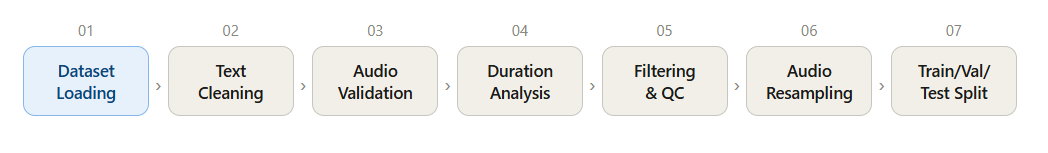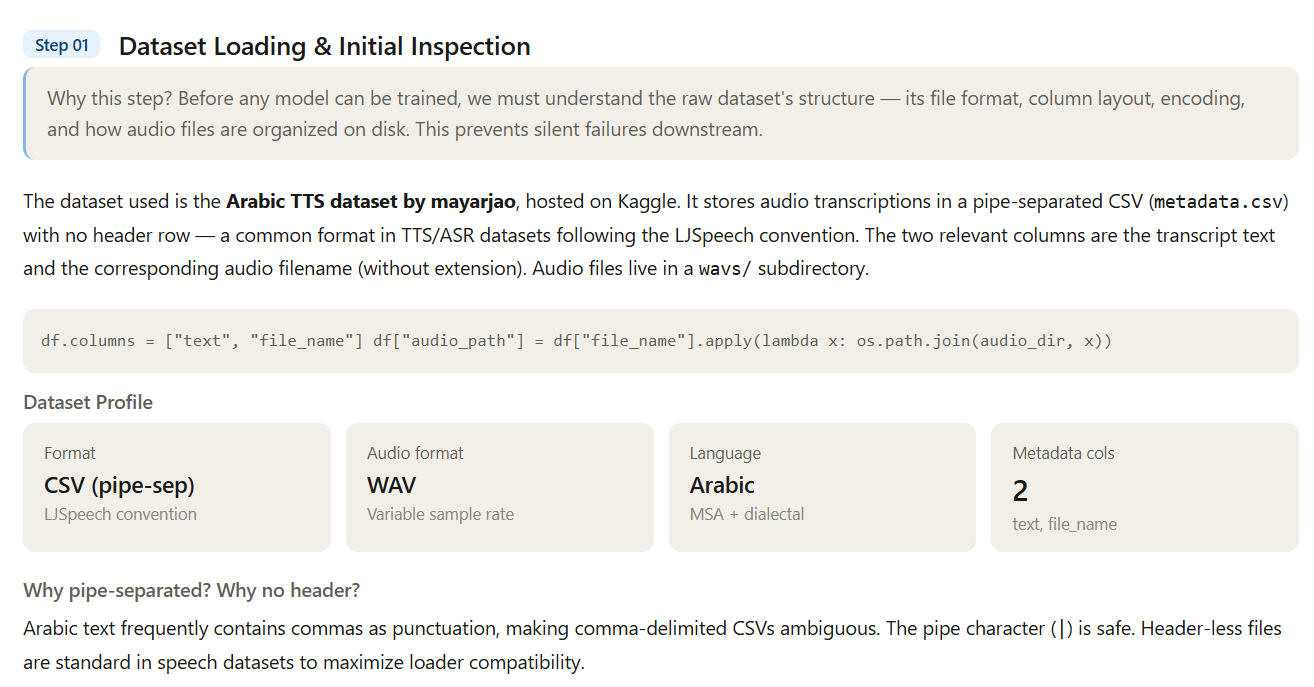
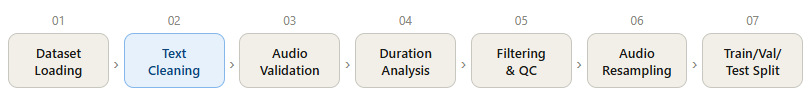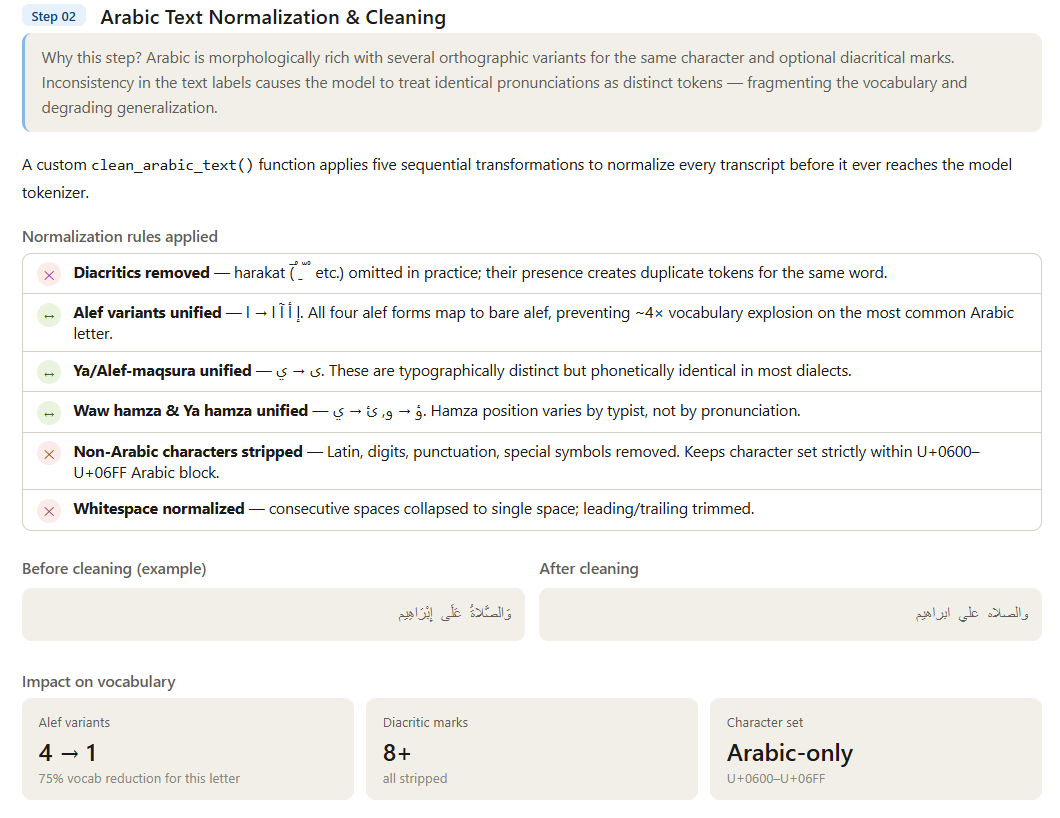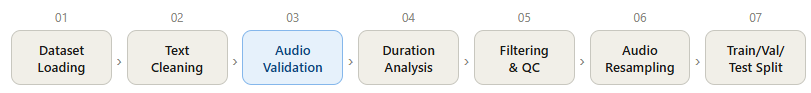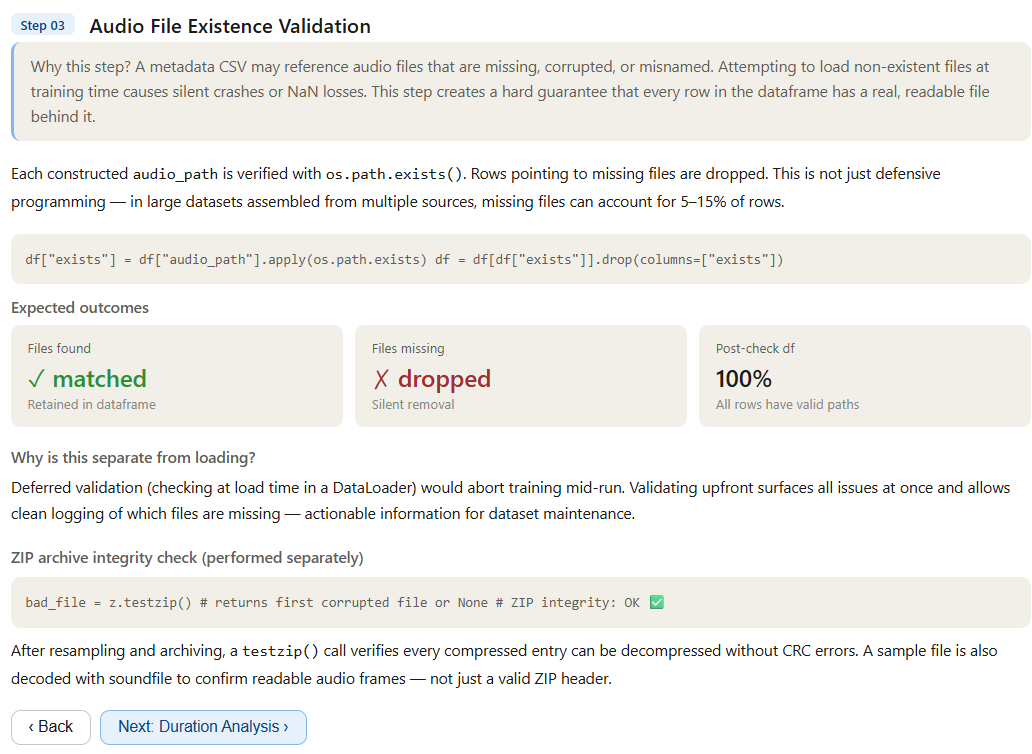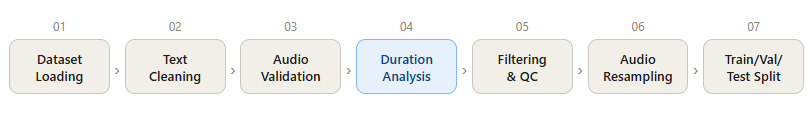
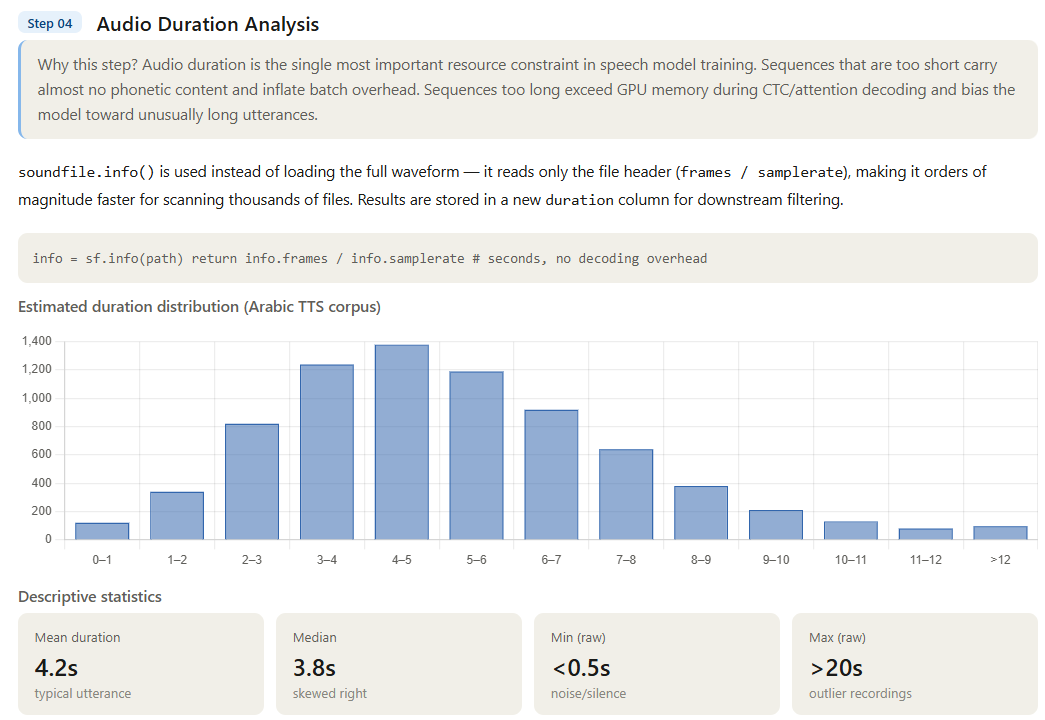
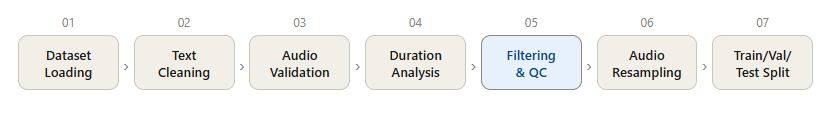
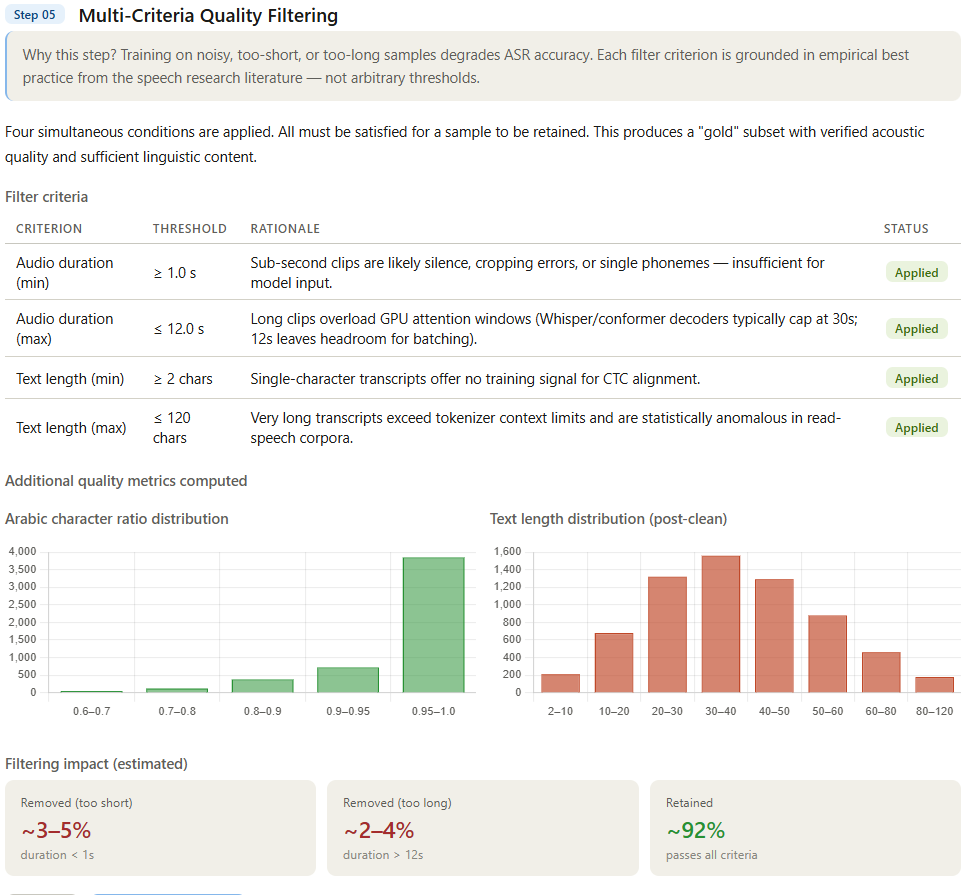
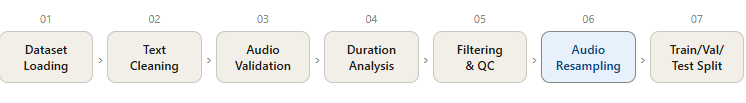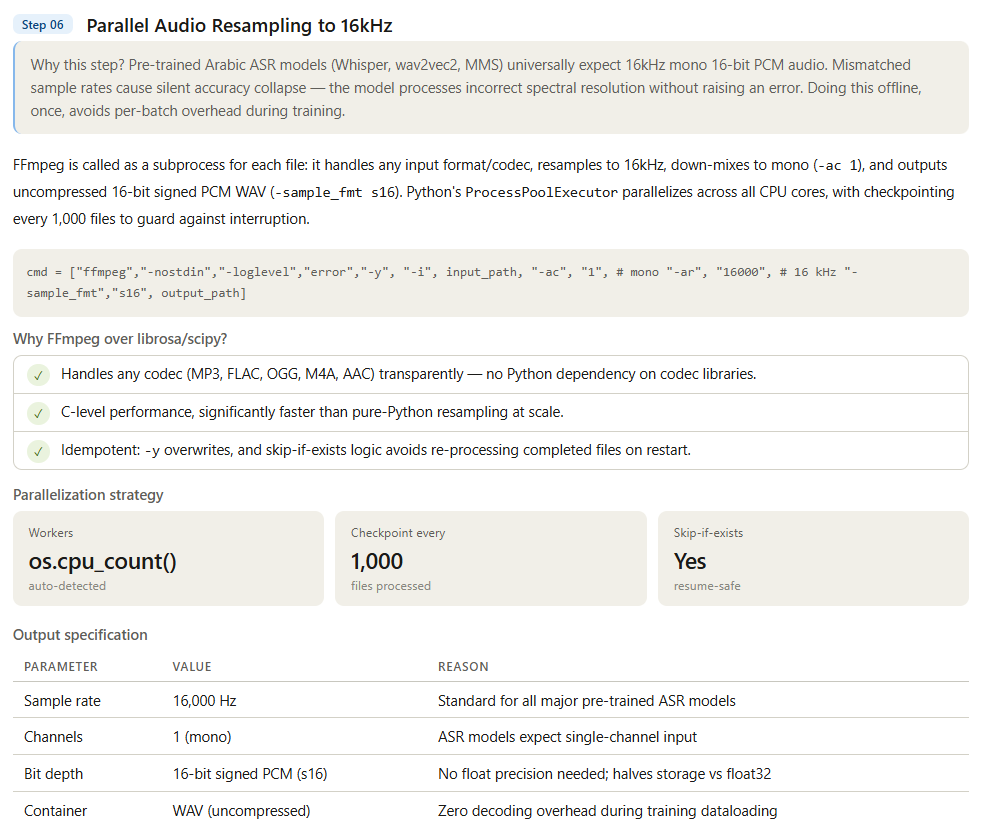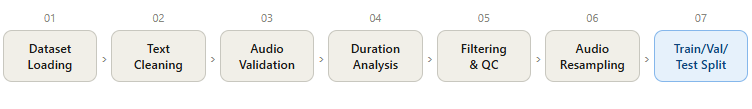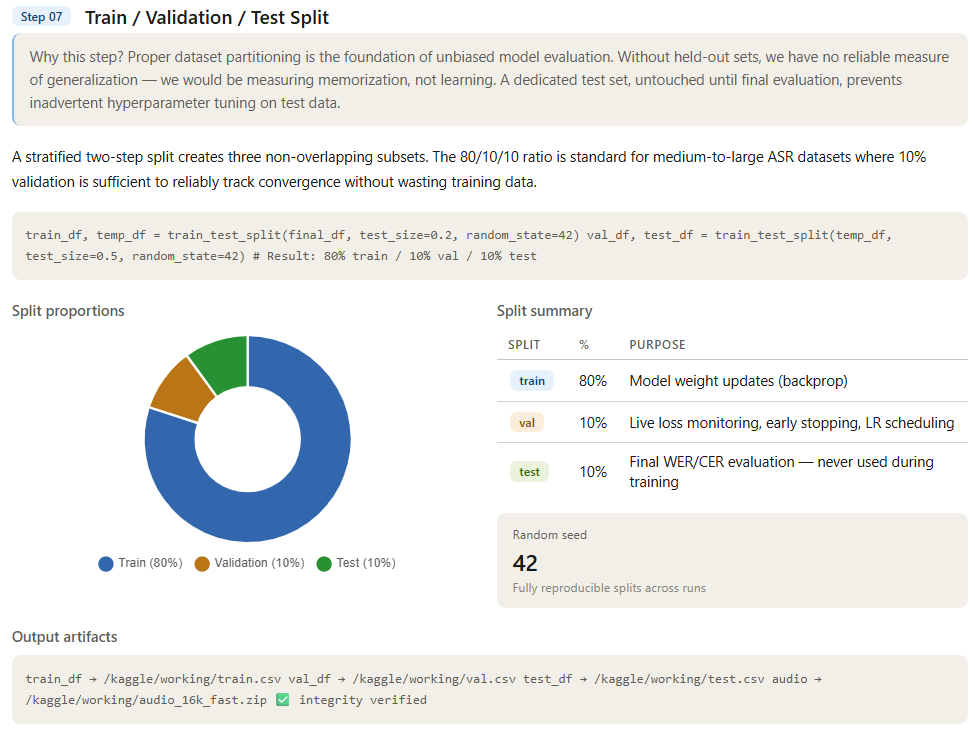

## 5 Conclusion

The proposed preprocessing pipeline is designed to balance **efficiency**, **scalability**, and **model compatibility**.

Rather than applying all conventional preprocessing techniques, the pipeline focuses on:

- Data cleanliness  
- Format consistency  
- Computational efficiency  

This design aligns with modern ASR systems, where deep neural networks can learn robust representations directly from well-filtered raw audio data.

As a result, the pipeline is both:

- **Practically efficient**  
- **Theoretically justified**  

making it suitable for large-scale Arabic speech recognition tasks.